# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


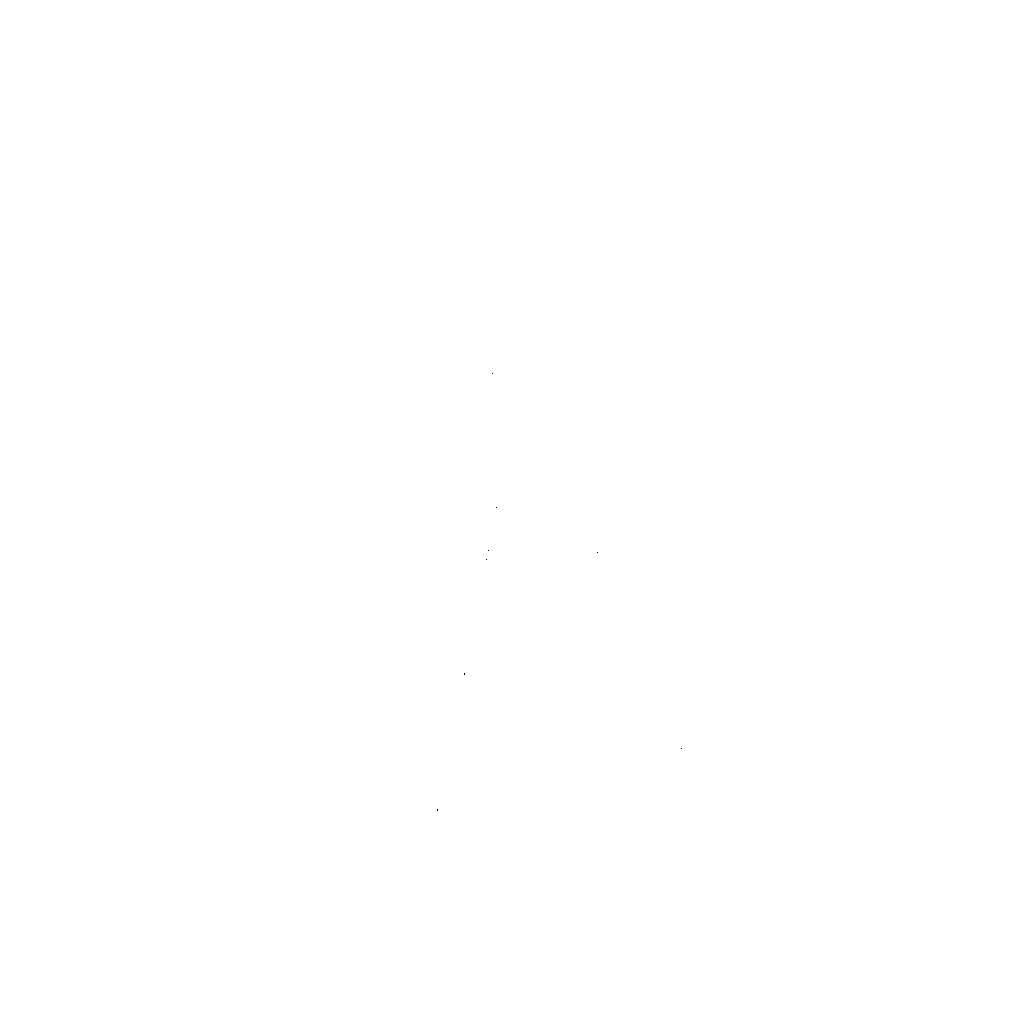

Threshold value: 50


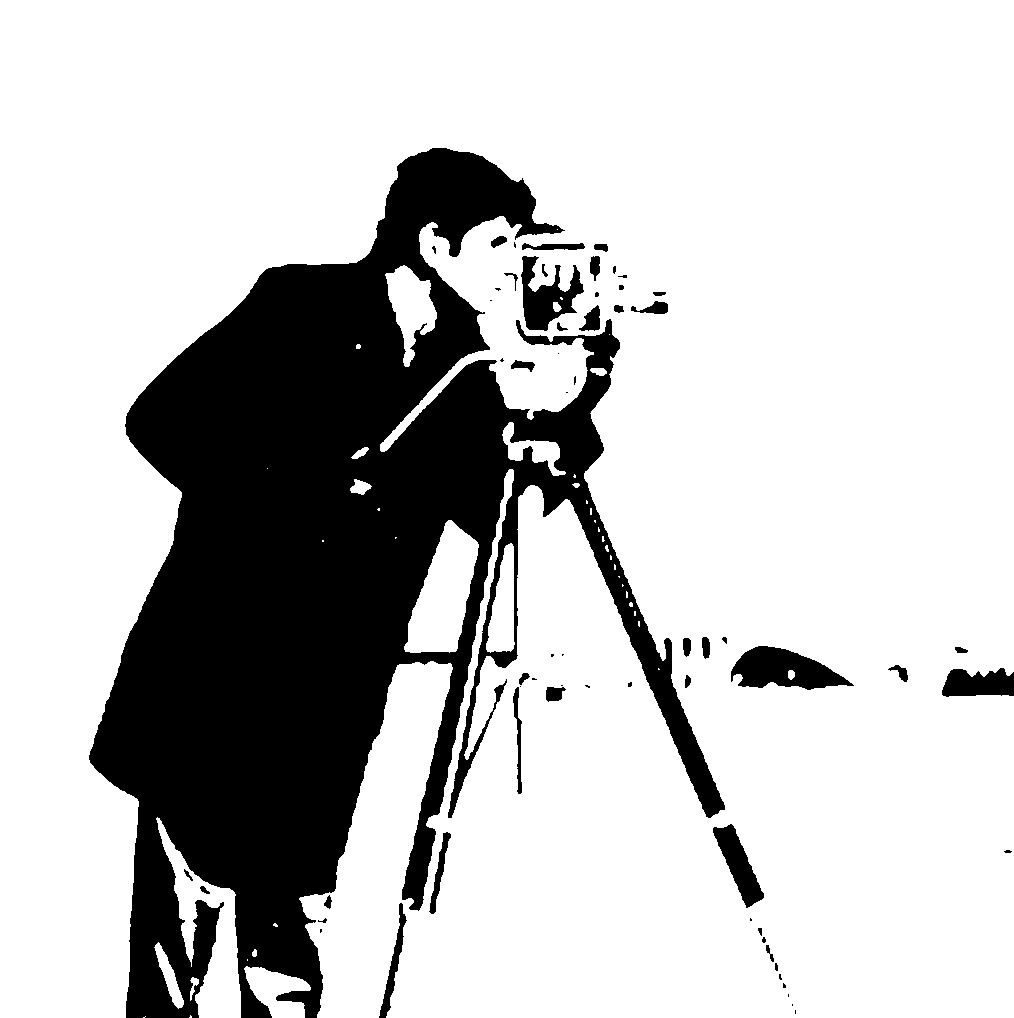

Threshold value: 100


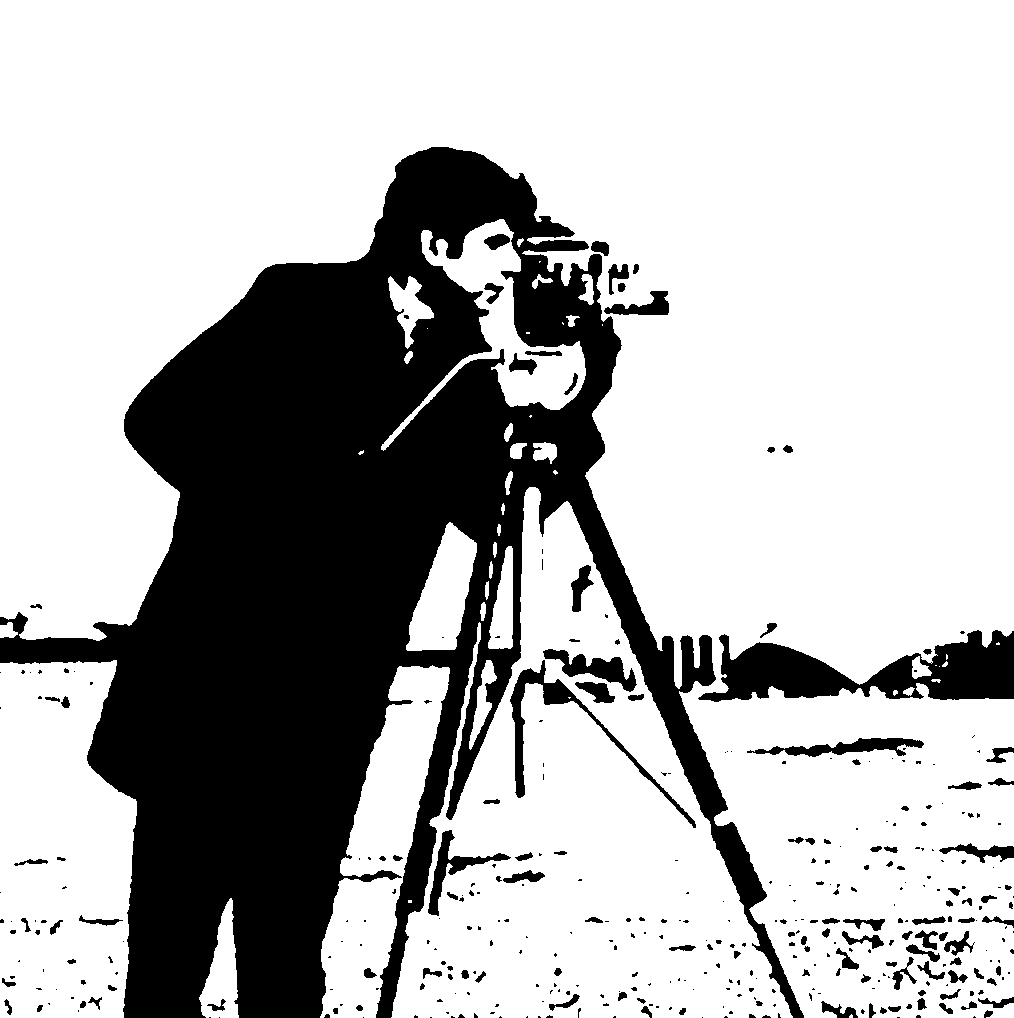

Threshold value: 150


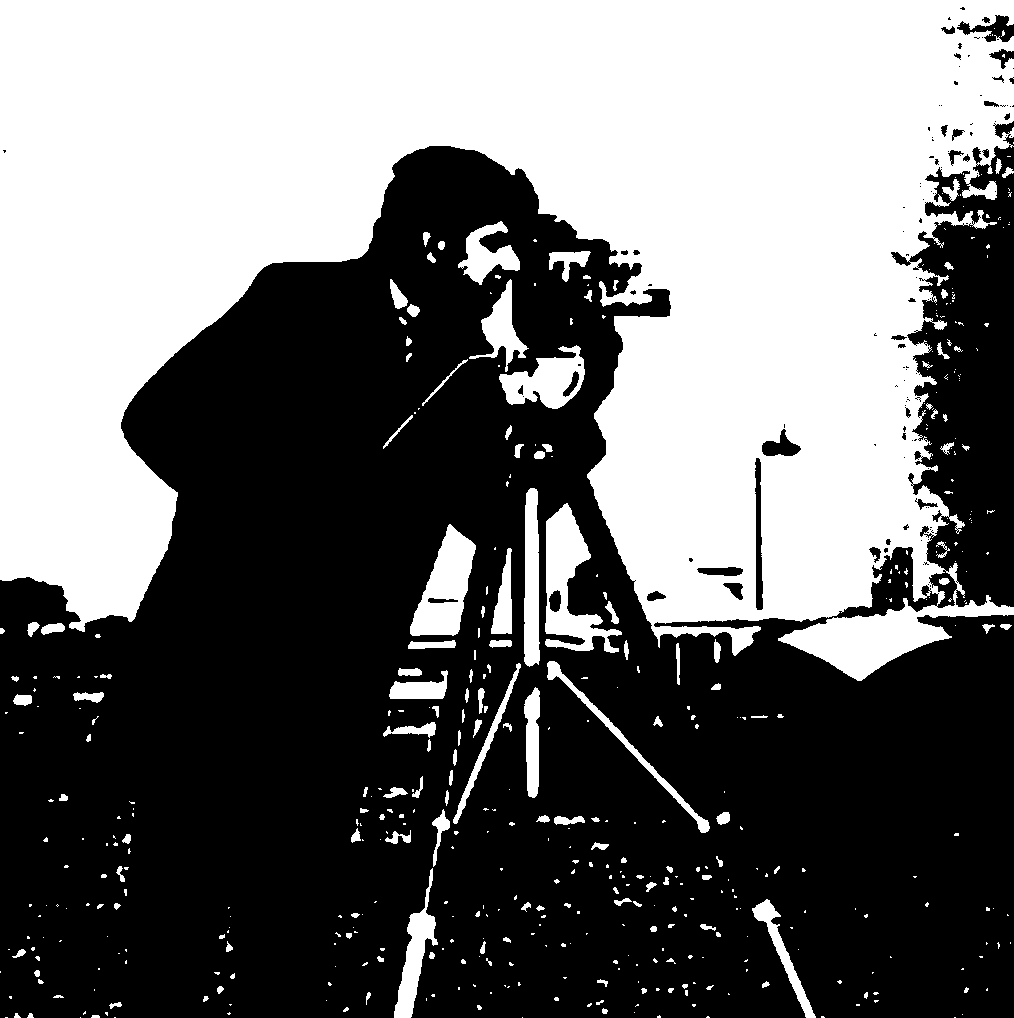

Threshold value: 200


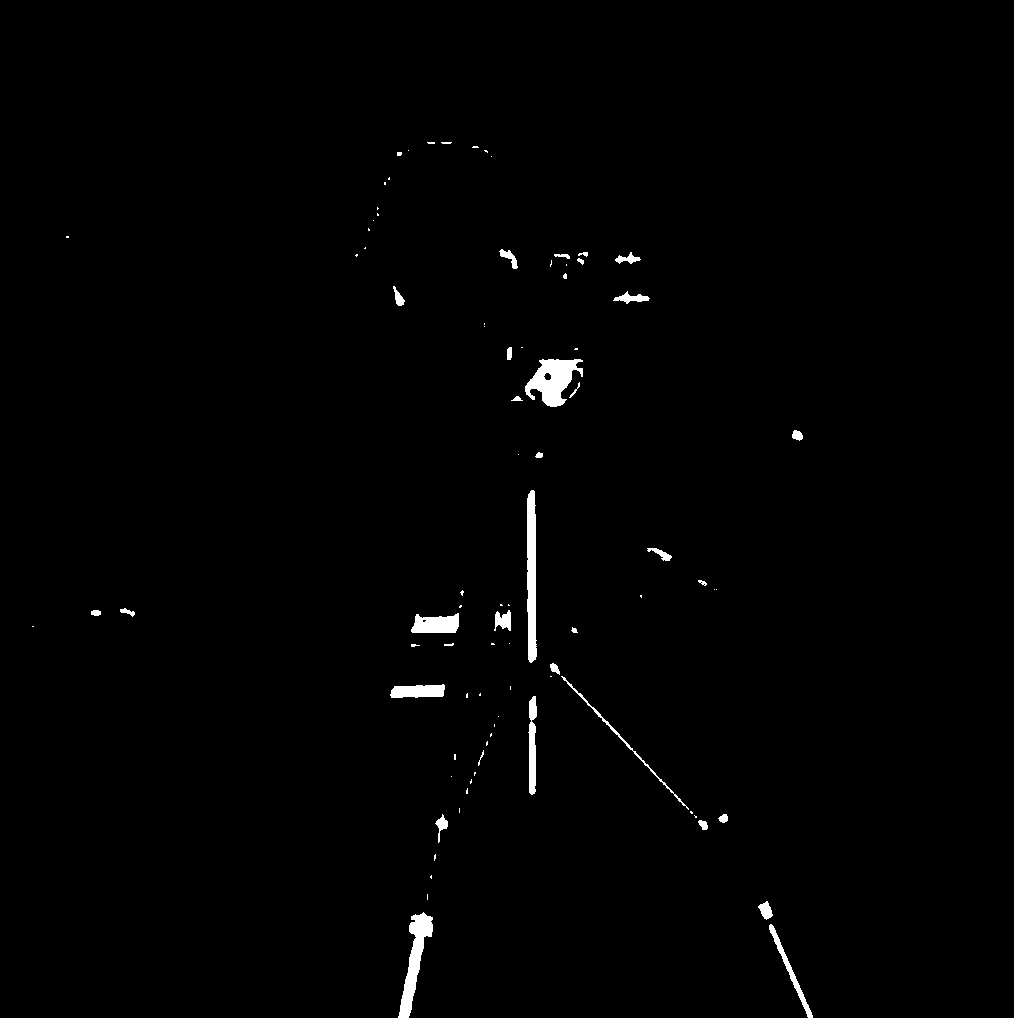

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


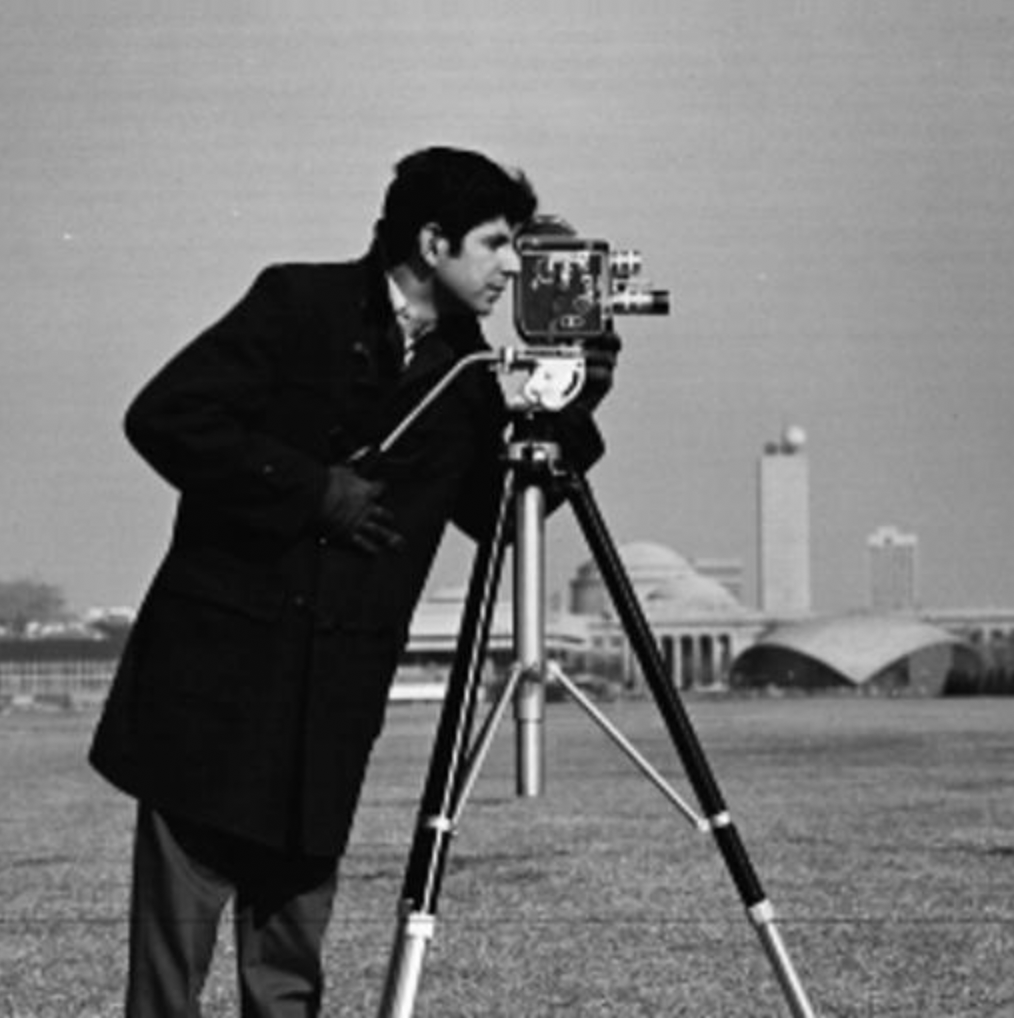

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

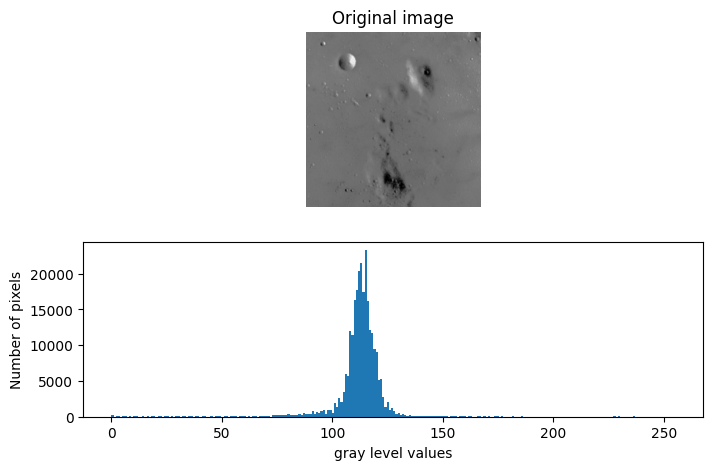

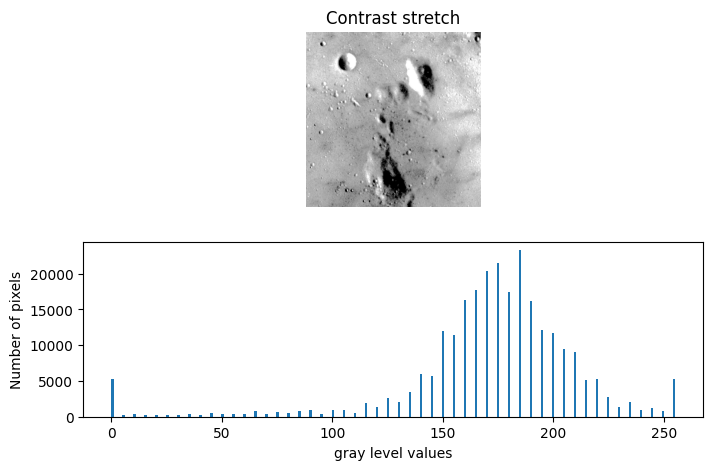

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


Task 1:

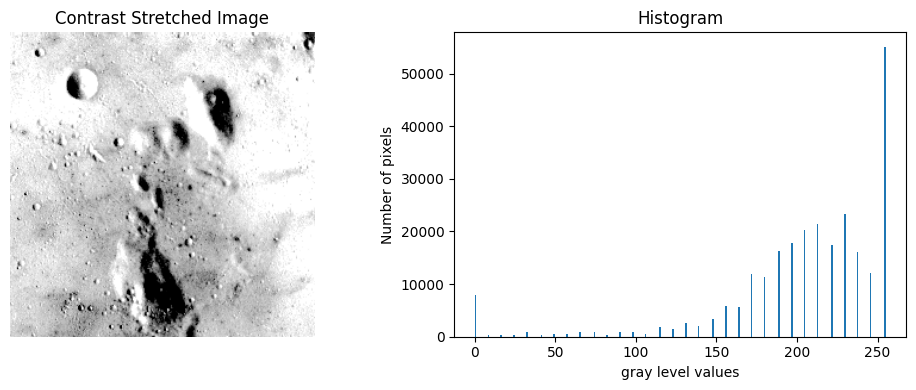

In [ ]:
# Task 1: Contrast Stretching

import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

# Load moon image
img = data.moon()

# Find the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale intensity values
img_rescale = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

# Display image and histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Rescaled image
axes[0].imshow(img_rescale, cmap='gray')
axes[0].set_title('Contrast Stretched Image')
axes[0].axis('off')

# Histogram
axes[1].hist(img_rescale.ravel(), bins=256)
axes[1].set_title('Histogram')
plt.xlabel( "gray level values")
plt.ylabel("Number of pixels")
plt.tight_layout()
plt.show()

Task 2:

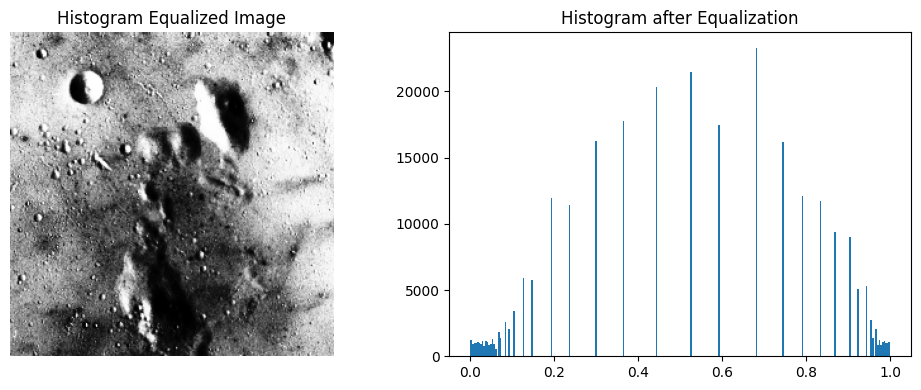

In [ ]:
# Task 2: Histogram Equalization

import matplotlib.pyplot as plt
from skimage import data, exposure

# Load moon image
img = data.moon()

# Apply histogram equalization
img_equalized = exposure.equalize_hist(img)

# Display the image and histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Equalized image
axes[0].imshow(img_equalized, cmap='gray')
axes[0].set_title('Histogram Equalized Image')
axes[0].axis('off')

# Histogram after equalization
axes[1].hist(img_equalized.ravel(), bins=256)
axes[1].set_title('Histogram after Equalization')
plt.xlabel("gray level values")
plt,ylabel("Number of pixela")
plt.tight_layout()
plt.show()

Task 3:

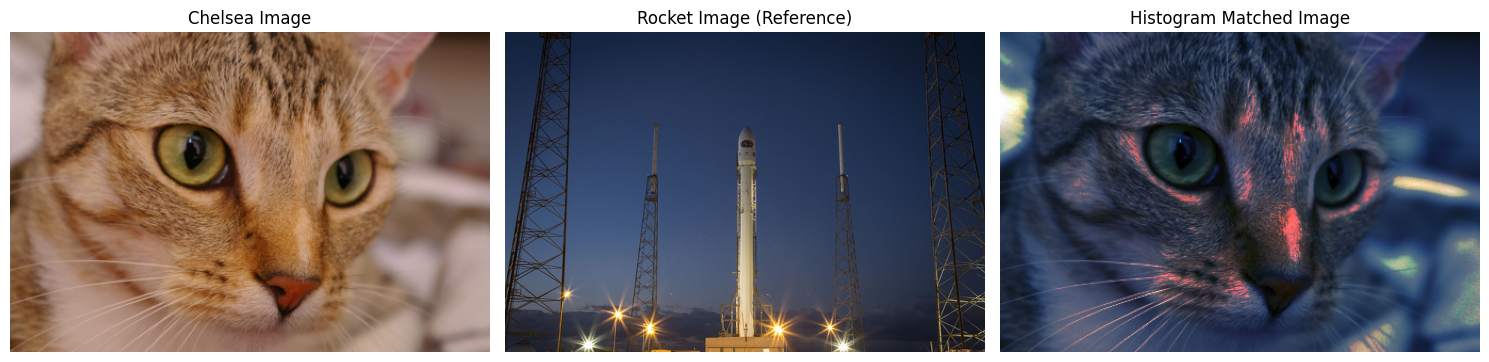

In [ ]:
# Task 3: Histogram Matching

import matplotlib.pyplot as plt
from skimage import data, exposure

# Load images
reference = data.rocket()
image = data.chelsea()

# Histogram matching
matched = exposure.match_histograms(image, reference, channel_axis=-1)

# Display the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title('Chelsea Image')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Rocket Image (Reference)')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Histogram Matched Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()